In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import random

# Early Stopping 클래스
class EarlyStopping:
    def __init__(self, patience=10, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# 데이터셋 로드 및 클래스 필터링 함수
def load_datasets(train_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_train_dataset_v2.npz',
                  val_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_val_dataset_v2.npz',
                  test_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_test_dataset_v2.npz',
                  top_n_classes=150):
    try:
        train_data = np.load(train_path, allow_pickle=True)
        X_train = {
            'pose': train_data['X_pose'],
            'left_hand': train_data['X_left_hand'],
            'right_hand': train_data['X_right_hand'],
            'face': train_data['X_face']
        }
        y_train = train_data['y']
        label_map = train_data['label_to_id'].item()

        val_data = np.load(val_path, allow_pickle=True)
        X_val = {
            'pose': val_data['X_pose'],
            'left_hand': val_data['X_left_hand'],
            'right_hand': val_data['X_right_hand'],
            'face': val_data['X_face']
        }
        y_val = val_data['y']

        test_data = np.load(test_path, allow_pickle=True)
        X_test = {
            'pose': test_data['X_pose'],
            'left_hand': test_data['X_left_hand'],
            'right_hand': test_data['X_right_hand'],
            'face': test_data['X_face']
        }
        y_test = test_data['y']

        id_to_label = {v: k for k, v in label_map.items()}
        label_counts = {}
        for y in y_train:
            label = id_to_label[y]
            label_counts[label] = label_counts.get(label, 0) + 1

        sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:top_n_classes]
        selected_labels = {label: idx for idx, (label, _) in enumerate(sorted_labels)}

        def filter_data(X, y):
            mask = np.array([id_to_label[y_i] in selected_labels for y_i in y])
            filtered_X = {key: val[mask] for key, val in X.items()}
            filtered_y = np.array([selected_labels[id_to_label[y_i]] for y_i in y[mask]])
            return filtered_X, filtered_y

        X_train_filtered, y_train_filtered = filter_data(X_train, y_train)
        X_val_filtered, y_val_filtered = filter_data(X_val, y_val)
        X_test_filtered, y_test_filtered = filter_data(X_test, y_test)

        print(f"Filtered dataset: Train {len(y_train_filtered)}, Val {len(y_val_filtered)}, Test {len(y_test_filtered)} samples")
        print(f"Number of classes: {len(selected_labels)}")

        final_label_map = {label: idx for label, idx in selected_labels.items()}
        return (X_train_filtered, y_train_filtered), (X_val_filtered, y_val_filtered), (X_test_filtered, y_test_filtered), final_label_map

    except Exception as e:
        print(f"Error loading datasets: {str(e)}")
        raise

# Dataset 클래스 (증강 강화)
class SignDataset(Dataset):
    def __init__(self, X, y, label_map, face_weight=3.0):
        self.X = X
        self.y = y
        self.label_to_idx = label_map
        self.idx_to_label = {idx: label for label, idx in label_map.items()}
        self.face_weight = face_weight

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        face_features = self.X['face'][idx] * self.face_weight
        other_features = np.concatenate([
            self.X['pose'][idx],
            self.X['left_hand'][idx],
            self.X['right_hand'][idx]
        ], axis=1)
        features = np.concatenate([other_features, face_features], axis=1)
        features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-8)
        features = (features - np.mean(features)) / (np.std(features) + 1e-8)
        label = self.y[idx]
        return torch.tensor(features, dtype=torch.float32), label, {'data': [{'attributes': [{'name': self.idx_to_label[label]}]}]}

class PreprocessedSignDataset(Dataset):
    def __init__(self, dataset, split='train', augment=True):
        self.data = []
        self.split = split
        self.augment = augment and split == 'train'
        self.label_to_idx = dataset.label_to_idx
        self.idx_to_label = dataset.idx_to_label
        for idx in range(len(dataset)):
            features, label, morpheme_data = dataset[idx]
            if features.size(0) > 0:
                if self.augment:
                    augmented_samples = self._augment_sample(features, morpheme_data)
                    for aug_features, aug_morpheme in augmented_samples:
                        self.data.append({'features': aug_features, 'label': label, 'morpheme': aug_morpheme})
                else:
                    self.data.append({'features': features, 'label': label, 'morpheme': morpheme_data})

    def _augment_sample(self, features, morpheme):
        augmented = [(features, morpheme)]
        aug_features = self.time_scale_augment(features, scale_range=(0.85, 1.15))
        augmented.append((aug_features, morpheme))
        aug_features = self.noise_augment(features, noise_level=0.05)
        augmented.append((aug_features, morpheme))
        aug_features = self.spatial_transform(features, max_shift=0.07)
        augmented.append((aug_features, morpheme))
        aug_features = self.mirror_augment(features)
        augmented.append((aug_features, morpheme))
        aug_features = self.rotation_augment(features, max_angle=15)
        augmented.append((aug_features, morpheme))
        return augmented

    def time_scale_augment(self, sequence, scale_range=(0.85, 1.15)):
        scale = random.uniform(*scale_range)
        length = max(1, int(len(sequence) * scale))
        sequence = sequence.transpose(0, 1).unsqueeze(0)
        resampled = F.interpolate(sequence, size=length, mode='linear', align_corners=True)
        if length < 150:
            resampled = F.pad(resampled, (0, 150 - length), mode='constant', value=0)
        elif length > 150:
            resampled = resampled[:, :, :150]
        return resampled.squeeze(0).transpose(0, 1)

    def noise_augment(self, sequence, noise_level=0.05):
        noise = torch.randn_like(sequence) * noise_level
        return sequence + noise

    def spatial_transform(self, sequence, max_shift=0.07):
        shift = torch.randn_like(sequence) * max_shift
        return sequence + shift

    def mirror_augment(self, sequence):
        mirrored = sequence.clone()
        mirrored[:, ::2] = -mirrored[:, ::2]
        return mirrored

    def rotation_augment(self, sequence, max_angle=15):
        angle = random.uniform(-max_angle, max_angle)
        theta = torch.tensor([[np.cos(np.radians(angle)), -np.sin(np.radians(angle))],
                              [np.sin(np.radians(angle)), np.cos(np.radians(angle))]], dtype=torch.float32)
        rotated = sequence.clone()
        for i in range(0, sequence.shape[1], 3):
            xy = rotated[:, i:i+2]
            rotated[:, i:i+2] = torch.matmul(xy, theta.to(sequence.device))
        return rotated

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return item['features'], item['label'], item['morpheme']

# 크로스 어텐션 모듈 (수정됨)
class CrossModalAttention(nn.Module):
    def __init__(self, pose_dim, hand_dim, face_dim):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=4)
        self.value_proj = nn.Linear(face_dim, 128)  # face 차원 256 -> 128
        self.out_proj = nn.Linear(128 + 256 + 128, 384)  # pose(128) + hands(256) + attn_output(128)

    def forward(self, pose_features, left_hand_features, right_hand_features, face_features):
        pose = pose_features.permute(2, 0, 1)  # [seq_len, batch_size, 128]
        hands = torch.cat([left_hand_features, right_hand_features], dim=1).permute(2, 0, 1)  # [seq_len, batch_size, 256]
        face = face_features.permute(2, 0, 1)  # [seq_len, batch_size, 256]
        Q = pose
        K = hands[:, :, :128]  # 손 특징 일부만 사용
        V = self.value_proj(face)  # face를 256 -> 128로 변환
        attn_output, _ = self.attention(Q, K, V)  # [seq_len, batch_size, 128]
        fused = torch.cat([pose, hands, attn_output], dim=2)  # [seq_len, batch_size, 512]
        fused = self.out_proj(fused.permute(1, 0, 2))  # [batch_size, seq_len, 384]
        return fused.permute(0, 2, 1)  # [batch_size, 384, seq_len]

# 멀티모달 특징 융합 모듈
class ModalityFusionModule(nn.Module):
    def __init__(self, pose_dim=75, left_hand_dim=63, right_hand_dim=63, face_dim=210):
        super().__init__()
        self.pose_encoder = nn.Sequential(
            nn.Conv1d(pose_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.left_hand_encoder = nn.Sequential(
            nn.Conv1d(left_hand_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.right_hand_encoder = nn.Sequential(
            nn.Conv1d(right_hand_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.face_encoder = nn.Sequential(
            nn.Conv1d(face_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        self.cross_attention = CrossModalAttention(128, 128, 256)

    def forward(self, x):
        pose = x[:, :, :75]
        left_hand = x[:, :, 75:138]
        right_hand = x[:, :, 138:201]
        face = x[:, :, 201:]
        pose_features = self.pose_encoder(pose.transpose(1, 2))
        left_hand_features = self.left_hand_encoder(left_hand.transpose(1, 2))
        right_hand_features = self.right_hand_encoder(right_hand.transpose(1, 2))
        face_features = self.face_encoder(face.transpose(1, 2))
        fused_features = self.cross_attention(pose_features, left_hand_features, right_hand_features, face_features)
        return fused_features

# TCNClassifier
class TCNClassifier(nn.Module):
    def __init__(self, input_size=411, num_classes=150):
        super().__init__()
        self.fusion_module = ModalityFusionModule()
        self.tcn_layers = nn.ModuleList([
            nn.Conv1d(384, 384, kernel_size=3, padding=dilation*1, dilation=dilation)
            for dilation in [1, 2, 4, 8]
        ])
        self.bn_layers = nn.ModuleList([nn.BatchNorm1d(384) for _ in range(4)])
        self.dropout_tcn = nn.Dropout(0.3)
        self.fc1 = nn.Linear(384, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

        self.init_weights()

    def init_weights(self):
        for name, param in self.named_parameters():
            if 'conv' in name and 'weight' in name:
                nn.init.kaiming_normal_(param, mode='fan_out', nonlinearity='relu')
            elif 'fc' in name and 'weight' in name:
                if len(param.shape) >= 2:
                    nn.init.kaiming_normal_(param, mode='fan_out', nonlinearity='relu')
                else:
                    nn.init.normal_(param, std=0.01)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

    def forward(self, x):
        x = self.fusion_module(x)
        for conv, bn in zip(self.tcn_layers, self.bn_layers):
            residual = x
            x = F.relu(bn(conv(x)))
            x = self.dropout_tcn(x)
            if x.size(2) == residual.size(2):
                x = x + residual
        x = x.mean(dim=2)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def collate_fn(batch):
    sequences = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    morphemes = [item[2]['data'][0]['attributes'][0]['name'] for item in batch]
    padded_sequences = pad_sequence(sequences, batch_first=True)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_sequences, labels, morphemes

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    processed_batches = 0
    for sequences, labels, _ in dataloader:
        sequences, labels = sequences.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        processed_batches += 1
    avg_loss = total_loss / processed_batches
    scheduler.step(avg_loss)
    return avg_loss, 100. * correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    with torch.no_grad():
        for sequences, labels, _ in dataloader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct_top1 += predicted.eq(labels).sum().item()
            _, top5_pred = outputs.topk(5, dim=1)
            for i in range(labels.size(0)):
                if labels[i] in top5_pred[i]:
                    correct_top5 += 1
    avg_loss = total_loss / len(dataloader)
    top1_acc = 100. * correct_top1 / total
    top5_acc = 100. * correct_top5 / total
    return avg_loss, top1_acc, top5_acc

if __name__ == "__main__":
    top_n_classes = 300
    print(f"Loading datasets with {top_n_classes} classes...")
    (X_train, y_train), (X_val, y_val), (X_test, y_test), label_map = load_datasets(top_n_classes=top_n_classes)

    train_dataset = SignDataset(X_train, y_train, label_map, face_weight=3.0)
    val_dataset = SignDataset(X_val, y_val, label_map, face_weight=3.0)
    test_dataset = SignDataset(X_test, y_test, label_map, face_weight=3.0)

    print(f"\nTotal training samples: {len(train_dataset)}")
    print(f"Total validation samples: {len(val_dataset)}")
    print(f"Total test samples: {len(test_dataset)}")
    print(f"Number of classes: {len(train_dataset.label_to_idx)}\n")

    processed_train_dataset = PreprocessedSignDataset(train_dataset, split='train', augment=True)
    processed_val_dataset = PreprocessedSignDataset(val_dataset, split='validation', augment=False)
    processed_test_dataset = PreprocessedSignDataset(test_dataset, split='test', augment=False)

    print("\n전처리 결과:")
    print(f"원본 훈련 데이터 크기: {len(train_dataset)}")
    print(f"전처리된 훈련 데이터 크기: {len(processed_train_dataset)}")
    print(f"원본 검증 데이터 크기: {len(val_dataset)}")
    print(f"전처리된 검증 데이터 크기: {len(processed_val_dataset)}")
    print(f"원본 테스트 데이터 크기: {len(test_dataset)}")
    print(f"전처리된 테스트 데이터 크기: {len(processed_test_dataset)}")

    train_loader = DataLoader(processed_train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(processed_val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(processed_test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TCNClassifier(input_size=411, num_classes=len(train_dataset.label_to_idx)).to(device)

    class_counts = np.bincount(y_train, minlength=len(label_map))
    class_weights = 1.0 / (class_counts + 1e-6)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)
    early_stopping = EarlyStopping(patience=10, verbose=True, path='best_tcn_improved_model.pt')

    # History 딕셔너리 초기화
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_top5_acc': []
    }

    num_epochs = 50
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_loss, val_acc, val_top5_acc = evaluate(model, val_loader, criterion, device)

        # History에 값 추가
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_top5_acc'].append(val_top5_acc)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val Top-5 Acc: {val_top5_acc:.2f}%")
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    # 최적 모델 로드 및 테스트
    model.load_state_dict(torch.load('best_tcn_improved_model.pt'))
    test_loss, test_acc, test_top5_acc = evaluate(model, test_loader, criterion, device)
    print("\nTest Results:")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, Test Top-5 Acc: {test_top5_acc:.2f}%")
    print("Training and evaluation completed!")

    # History 출력 (선택적)
    print("\nTraining History:")
    for epoch in range(len(history['train_loss'])):
        print(f"Epoch {epoch+1}: Train Loss: {history['train_loss'][epoch]:.4f}, "
              f"Train Acc: {history['train_acc'][epoch]:.2f}%, "
              f"Val Loss: {history['val_loss'][epoch]:.4f}, "
              f"Val Acc: {history['val_acc'][epoch]:.2f}%, "
              f"Val Top-5 Acc: {history['val_top5_acc'][epoch]:.2f}%")

Loading datasets with 300 classes...
Filtered dataset: Train 2449, Val 2736, Test 1154 samples
Number of classes: 300

Total training samples: 2449
Total validation samples: 2736
Total test samples: 1154
Number of classes: 300


전처리 결과:
원본 훈련 데이터 크기: 2449
전처리된 훈련 데이터 크기: 14694
원본 검증 데이터 크기: 2736
전처리된 검증 데이터 크기: 2736
원본 테스트 데이터 크기: 1154
전처리된 테스트 데이터 크기: 1154
Epoch 1/50
Train Loss: 5.2512, Train Acc: 3.00%
Val Loss: 4.2575, Val Acc: 10.82%, Val Top-5 Acc: 35.27%
Validation loss decreased (inf --> 4.257502). Saving model ...
Epoch 2/50
Train Loss: 3.3056, Train Acc: 27.95%
Val Loss: 2.9286, Val Acc: 34.43%, Val Top-5 Acc: 70.72%
Validation loss decreased (4.257502 --> 2.928586). Saving model ...
Epoch 3/50
Train Loss: 1.9435, Train Acc: 61.88%
Val Loss: 1.8637, Val Acc: 62.21%, Val Top-5 Acc: 88.38%
Validation loss decreased (2.928586 --> 1.863736). Saving model ...
Epoch 4/50
Train Loss: 1.1464, Train Acc: 79.02%
Val Loss: 1.6198, Val Acc: 60.23%, Val Top-5 Acc: 87.50%
Validation loss de

<ipython-input-2-3f323b46cef6>:432: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_tcn_improved_model.pt'))



Test Results:
Test Loss: 0.4954, Test Acc: 88.13%, Test Top-5 Acc: 96.01%
Training and evaluation completed!

Training History:
Epoch 1: Train Loss: 5.2512, Train Acc: 3.00%, Val Loss: 4.2575, Val Acc: 10.82%, Val Top-5 Acc: 35.27%
Epoch 2: Train Loss: 3.3056, Train Acc: 27.95%, Val Loss: 2.9286, Val Acc: 34.43%, Val Top-5 Acc: 70.72%
Epoch 3: Train Loss: 1.9435, Train Acc: 61.88%, Val Loss: 1.8637, Val Acc: 62.21%, Val Top-5 Acc: 88.38%
Epoch 4: Train Loss: 1.1464, Train Acc: 79.02%, Val Loss: 1.6198, Val Acc: 60.23%, Val Top-5 Acc: 87.50%
Epoch 5: Train Loss: 0.7356, Train Acc: 87.28%, Val Loss: 1.0893, Val Acc: 76.97%, Val Top-5 Acc: 92.11%
Epoch 6: Train Loss: 0.5308, Train Acc: 91.19%, Val Loss: 1.0361, Val Acc: 77.08%, Val Top-5 Acc: 92.73%
Epoch 7: Train Loss: 0.4278, Train Acc: 92.89%, Val Loss: 0.9939, Val Acc: 78.73%, Val Top-5 Acc: 92.36%
Epoch 8: Train Loss: 0.3546, Train Acc: 94.30%, Val Loss: 0.9717, Val Acc: 79.64%, Val Top-5 Acc: 92.95%
Epoch 9: Train Loss: 0.3054, Tra

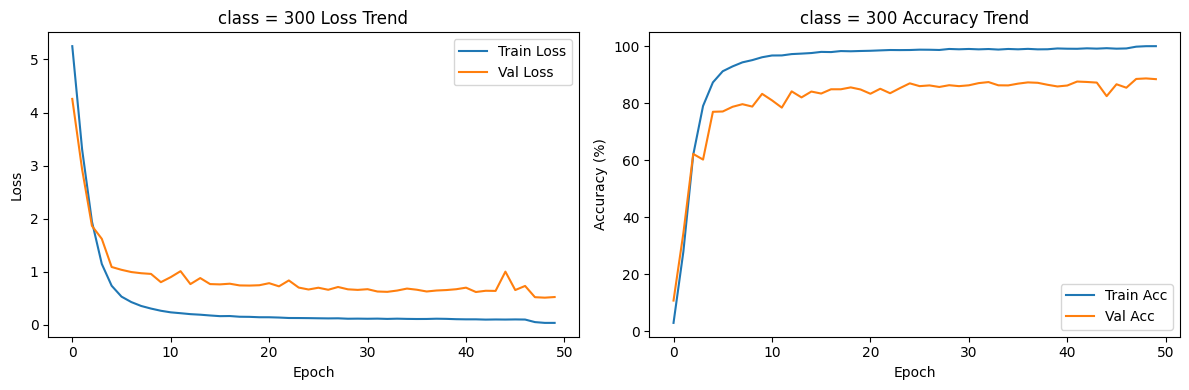

In [ ]:
# acc loss 함수 그리기
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'class = {top_n_classes} Loss Trend')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
# plt.plot(history['val_top5_acc'], label='Val Top-5 Acc')
plt.title(f'class = {top_n_classes} Accuracy Trend')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 수어 번역
def run_translation_test(model, test_dataset, device, label_map, num_samples=10):
    """
    랜덤하게 선택된 샘플들에 대해 모델의 수어 번역 성능을 테스트하고 결과를 출력합니다.

    Args:
        model: 학습된 TCN 모델
        test_dataset: 테스트 데이터셋
        device: 사용할 장치 (CPU/GPU)
        label_map: 라벨-인덱스 매핑 딕셔너리
        num_samples: 테스트할 랜덤 샘플 수
    """
    print(f"\n=== 수어 번역 테스트 (랜덤 {num_samples}개 샘플) ===")

    # 인덱스-라벨 매핑 생성
    idx_to_label = {idx: label for label, idx in label_map.items()}

    # 랜덤 샘플 인덱스 선택
    total_samples = len(test_dataset)
    random_indices = random.sample(range(total_samples), min(num_samples, total_samples))

    model.eval()
    correct_count = 0

    with torch.no_grad():
        for i, idx in enumerate(random_indices):
            # 단일 샘플 가져오기
            sequence, label, morpheme = test_dataset[idx]
            sequence = sequence.unsqueeze(0).to(device)  # 배치 차원 추가
            label = torch.tensor([label]).to(device)

            # 모델 예측
            output = model(sequence)
            _, predicted = output.max(1)

            # Top-5 예측 가져오기
            _, top5_pred = output.topk(5, dim=1)

            # 예측이 맞았는지 확인
            correct = predicted[0].item() == label[0].item()
            if correct:
                correct_count += 1

            print(f"\n샘플 {i + 1} (데이터셋 인덱스: {idx}):")
            if isinstance(morpheme, dict):
                morpheme = morpheme['data'][0]['attributes'][0]['name']
            print(f"실제 라벨: {morpheme}")
            print(f"예측 라벨: {idx_to_label[predicted[0].item()]}")

            # Top-5 예측 출력
            print("Top-5 예측:")
            for k in range(5):
                pred_idx = top5_pred[0][k].item()
                pred_label = idx_to_label[pred_idx]
                pred_prob = torch.softmax(output[0], dim=0)[pred_idx].item()
                print(f"  {k+1}. {pred_label} ({pred_prob:.2%})")

            print(f"예측 결과: {'✓ 정확함' if correct else '✗ 부정확함'}")

    # 최종 정확도 출력
    accuracy = (correct_count / num_samples) * 100
    print(f"\n=== 최종 결과 ===")
    print(f"테스트한 샘플 수: {num_samples}")
    print(f"정확히 예측한 샘플 수: {correct_count}")
    print(f"정확도: {accuracy:.2f}%")

# 테스트 실행
print("번역 테스트 시작...")
model.load_state_dict(torch.load('best_tcn_improved_model.pt'))
run_translation_test(model, processed_test_dataset, device, train_dataset.label_to_idx, num_samples=10)

번역 테스트 시작...

=== 수어 번역 테스트 (랜덤 10개 샘플) ===

샘플 1 (데이터셋 인덱스: 7):
실제 라벨: 가산로
예측 라벨: 가산로
Top-5 예측:
  1. 가산로 (99.58%)
  2. 신사로 (0.05%)
  3. 자하문로 (0.04%)
  4. 장한로 (0.03%)
  5. 성미산로 (0.02%)
예측 결과: ✓ 정확함

샘플 2 (데이터셋 인덱스: 938):
실제 라벨: 한빛로
예측 라벨: 한빛로
Top-5 예측:
  1. 한빛로 (99.90%)
  2. 해등로 (0.01%)
  3. 대학로 (0.01%)
  4. 난우길 (0.01%)
  5. 한천로 (0.01%)
예측 결과: ✓ 정확함

샘플 3 (데이터셋 인덱스: 385):
실제 라벨: 15분
예측 라벨: 2
Top-5 예측:
  1. 2 (25.48%)
  2. 41분 (24.48%)
  3. 15분 (23.88%)
  4. 11달 (18.16%)
  5. 45분 (1.39%)
예측 결과: ✗ 부정확함

샘플 4 (데이터셋 인덱스: 551):
실제 라벨: 도산대로
예측 라벨: 도산대로
Top-5 예측:
  1. 도산대로 (99.85%)
  2. 녹사평대로 (0.03%)
  3. 잔다리로 (0.02%)
  4. 두산로 (0.01%)
  5. 마포대로 (0.01%)
예측 결과: ✓ 정확함

샘플 5 (데이터셋 인덱스: 46):
실제 라벨: 국립중앙박물관
예측 라벨: 국립중앙박물관
Top-5 예측:
  1. 국립중앙박물관 (99.79%)
  2. 목동중앙북로 (0.09%)
  3. 35분 (0.02%)
  4. 충무로 (0.01%)
  5. 관악로 (0.01%)
예측 결과: ✓ 정확함

샘플 6 (데이터셋 인덱스: 500):
실제 라벨: 공덕
예측 라벨: 공덕
Top-5 예측:
  1. 공덕 (99.92%)
  2. 동작 (0.02%)
  3. 학동로 (0.01%)
  4. 창덕궁 (0.01%)
  5. 제기로 (0.01%)
예측 결과: ✓ 정확함

샘플 7 (데이터셋 인덱스

<ipython-input-10-d9272b6ed66c>:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_tcn_improved_model.pt'))


---

역방향 시작

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# 데이터셋 로드 (검증/테스트 포함)
def load_datasets(train_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_train_dataset_v2.npz',
                  val_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_val_dataset_v2.npz',
                  test_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_test_dataset_v2.npz',
                  top_n_classes=300):
    try:
        train_data = np.load(train_path, allow_pickle=True)
        X_train = {'pose': train_data['X_pose'], 'left_hand': train_data['X_left_hand'], 'right_hand': train_data['X_right_hand'], 'face': train_data['X_face']}
        y_train = train_data['y']
        label_map = train_data['label_to_id'].item()

        val_data = np.load(val_path, allow_pickle=True)
        X_val = {'pose': val_data['X_pose'], 'left_hand': val_data['X_left_hand'], 'right_hand': val_data['X_right_hand'], 'face': val_data['X_face']}
        y_val = val_data['y']

        test_data = np.load(test_path, allow_pickle=True)
        X_test = {'pose': test_data['X_pose'], 'left_hand': test_data['X_left_hand'], 'right_hand': test_data['X_right_hand'], 'face': test_data['X_face']}
        y_test = test_data['y']

        id_to_label = {v: k for k, v in label_map.items()}
        label_counts = {label: 0 for label in id_to_label.values()}
        for y in y_train:
            label_counts[id_to_label[y]] += 1

        sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:top_n_classes]
        selected_labels = {label: idx for idx, (label, _) in enumerate(sorted_labels)}

        def filter_data(X, y):
            mask = np.array([id_to_label[y_i] in selected_labels for y_i in y])
            filtered_X = {key: val[mask] for key, val in X.items()}
            filtered_y = np.array([selected_labels[id_to_label[y_i]] for y_i in y[mask]])
            return filtered_X, filtered_y

        X_train_filtered, y_train_filtered = filter_data(X_train, y_train)
        X_val_filtered, y_val_filtered = filter_data(X_val, y_val)
        X_test_filtered, y_test_filtered = filter_data(X_test, y_test)

        print(f"Filtered dataset: Train {len(y_train_filtered)}, Val {len(y_val_filtered)}, Test {len(y_test_filtered)} samples")
        print(f"Number of classes: {len(selected_labels)}")

        final_label_map = {label: idx for label, idx in selected_labels.items()}
        return (X_train_filtered, y_train_filtered), (X_val_filtered, y_val_filtered), (X_test_filtered, y_test_filtered), final_label_map

    except Exception as e:
        print(f"Error loading datasets: {str(e)}")
        raise

# 간소화된 SignDataset
class SignDataset(Dataset):
    def __init__(self, X, y, label_map):
        self.X = X
        self.y = y
        self.label_to_idx = label_map
        self.idx_to_label = {idx: label for label, idx in label_map.items()}

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        features = np.concatenate([self.X['pose'][idx], self.X['left_hand'][idx], self.X['right_hand'][idx], self.X['face'][idx]], axis=1)
        features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-8)
        label = self.y[idx]
        return torch.tensor(features, dtype=torch.float32), label

# 생성 모델
class SignSequenceGenerator(nn.Module):
    def __init__(self, num_classes=300, hidden_dim=512, output_dim=411, max_seq_len=150):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(num_classes, self.hidden_dim)
        self.encoder = nn.Linear(self.hidden_dim, self.hidden_dim)
        self.decoder = nn.LSTM(self.hidden_dim, self.hidden_dim, num_layers=2, batch_first=True)
        self.output_layer = nn.Linear(self.hidden_dim, output_dim)
        self.max_seq_len = max_seq_len

    def forward(self, labels):
        embedded = self.embedding(labels)
        encoded = torch.relu(self.encoder(embedded))
        h0 = encoded.unsqueeze(0).repeat(2, 1, 1)
        c0 = torch.zeros_like(h0)

        batch_size = labels.size(0)
        input_seq = torch.zeros(batch_size, 1, self.hidden_dim).to(labels.device)
        outputs = []
        hidden = (h0, c0)

        for _ in range(self.max_seq_len):
            output, hidden = self.decoder(input_seq, hidden)
            keypoint = self.output_layer(output)
            outputs.append(keypoint)
            input_seq = output

        return torch.cat(outputs, dim=1)

# 학습 함수 (디버깅 추가)
def train_generator(generator, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    for epoch in range(epochs):
        generator.train()  # 매 에포크마다 명시적으로 학습 모드 설정
        total_train_loss = 0
        print(f"Starting Epoch {epoch+1}/{epochs} - Model in training mode: {generator.training}")
        for batch_idx, (sequences, labels) in enumerate(train_loader):
            sequences, labels = sequences.to(device), labels.to(device)
            optimizer.zero_grad()
            pred_keypoints = generator(labels)
            loss = criterion(pred_keypoints, sequences)
            print(f"Batch {batch_idx+1}, Loss before backward: {loss.item()}")
            loss.backward()  # 여기서 에러 발생 여부 확인
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)

        generator.eval()
        total_val_loss = 0
        with torch.no_grad():
            for sequences, labels in val_loader:
                sequences, labels = sequences.to(device), labels.to(device)
                pred_keypoints = generator(labels)
                loss = criterion(pred_keypoints, sequences)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# 테스트 평가 함수
def evaluate_generator(generator, test_loader, criterion, device):
    generator.eval()
    total_test_loss = 0
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            pred_keypoints = generator(labels)
            loss = criterion(pred_keypoints, sequences)
            total_test_loss += loss.item()
    avg_test_loss = total_test_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss:.4f}")

# collate_fn
def collate_fn(batch):
    sequences = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    padded_sequences = pad_sequence(sequences, batch_first=True)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded_sequences, labels

# 실행
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 데이터 로드
    (X_train, y_train), (X_val, y_val), (X_test, y_test), label_map = load_datasets()
    train_dataset = SignDataset(X_train, y_train, label_map)
    val_dataset = SignDataset(X_val, y_val, label_map)
    test_dataset = SignDataset(X_test, y_test, label_map)

    # 데이터로더
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

    # 모델 설정
    generator = SignSequenceGenerator(num_classes=300, hidden_dim=512, output_dim=411, max_seq_len=150).to(device)
    optimizer = optim.Adam(generator.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    # 학습 및 검증
    train_generator(generator, train_loader, val_loader, criterion, optimizer, device)

    # 테스트
    evaluate_generator(generator, test_loader, criterion, device)

    # 생성 예시
    label = torch.tensor([0], dtype=torch.long).to(device)
    generated_keypoints = generator(label)
    print(generated_keypoints.shape)  # torch.Size([1, 150, 411])

Filtered dataset: Train 2449, Val 2745, Test 1168 samples
Number of classes: 300
Starting Epoch 1/50 - Model in training mode: True
Batch 1, Loss before backward: 0.9494162797927856
Batch 2, Loss before backward: 0.9439808130264282
Batch 3, Loss before backward: 0.9405730962753296
Batch 4, Loss before backward: 0.9455409646034241
Batch 5, Loss before backward: 0.9457533359527588
Batch 6, Loss before backward: 0.9397554993629456
Batch 7, Loss before backward: 1.0883995294570923
Batch 8, Loss before backward: 0.9378573298454285
Batch 9, Loss before backward: 0.9452301859855652
Batch 10, Loss before backward: 0.9379563331604004
Batch 11, Loss before backward: 0.9502213597297668
Batch 12, Loss before backward: 0.9471333622932434
Batch 13, Loss before backward: 0.939191460609436
Batch 14, Loss before backward: 0.9311589598655701
Batch 15, Loss before backward: 0.9366017580032349
Batch 16, Loss before backward: 0.9527410268783569
Batch 17, Loss before backward: 0.9526687860488892
Batch 18, L

KeyboardInterrupt: 

LSTM 역방향

In [31]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# 데이터 로드
def load_datasets(train_path='/content/drive/MyDrive/data/teamproject/npz/crowd_npz/crowd_train_dataset_v2.npz', top_n_classes=300):
    train_data = np.load(train_path, allow_pickle=True)
    X_train = {'pose': train_data['X_pose'], 'left_hand': train_data['X_left_hand'], 'right_hand': train_data['X_right_hand'], 'face': train_data['X_face']}
    y_train = train_data['y']
    label_map = train_data['label_to_id'].item()
    id_to_label = {v: k for k, v in label_map.items()}
    label_counts = {label: 0 for label in id_to_label.values()}
    for y in y_train:
        label_counts[id_to_label[y]] += 1
    sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)[:top_n_classes]
    selected_labels = {label: idx for idx, (label, _) in enumerate(sorted_labels)}
    mask = np.array([id_to_label[y_i] in selected_labels for y_i in y_train])
    X_train_filtered = {key: val[mask] for key, val in X_train.items()}
    y_train_filtered = np.array([selected_labels[id_to_label[y_i]] for y_i in y_train[mask]])
    return X_train_filtered, y_train_filtered, {label: idx for label, idx in selected_labels.items()}

class SignDataset(Dataset):
    def __init__(self, X, y, label_map):
        self.X = X
        self.y = y
        self.label_to_idx = label_map
        self.idx_to_label = {idx: label for label, idx in label_map.items()}
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        features = np.concatenate([self.X['pose'][idx], self.X['left_hand'][idx], self.X['right_hand'][idx], self.X['face'][idx]], axis=1)
        features = (features - np.mean(features, axis=0)) / (np.std(features, axis=0) + 1e-8)
        return torch.tensor(features, dtype=torch.float32), self.y[idx]

# 역방향 모델
class ReverseGenerator(nn.Module):
    def __init__(self, num_classes=300, hidden_dim=512, output_dim=411, seq_len=150):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(num_classes, self.hidden_dim)
        self.lstm = nn.LSTM(self.hidden_dim, self.hidden_dim, num_layers=2, batch_first=True)
        self.fc = nn.Linear(self.hidden_dim, output_dim)
        self.seq_len = seq_len

    def forward(self, labels):
        embedded = self.embedding(labels).unsqueeze(1)
        h0 = torch.zeros(2, labels.size(0), self.hidden_dim).to(labels.device)
        c0 = torch.zeros(2, labels.size(0), self.hidden_dim).to(labels.device)
        output, _ = self.lstm(embedded.expand(-1, self.seq_len, -1), (h0, c0))
        return self.fc(output)

# Early Stopping 클래스
class EarlyStopping:
    def __init__(self, patience=7, verbose=True, path='reverse_generator_best.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = float('inf')
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.4f} --> {val_loss:.4f}). Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# 학습
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train, y_train, label_map = load_datasets()
train_dataset = SignDataset(X_train, y_train, label_map)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=lambda batch: (pad_sequence([x[0] for x in batch], batch_first=True), torch.tensor([x[1] for x in batch], dtype=torch.long)))

model = ReverseGenerator().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=7, verbose=True)

for epoch in range(150):
    # 훈련
    model.train()
    train_loss = 0
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        optimizer.zero_grad()
        pred_keypoints = model(labels)
        loss = criterion(pred_keypoints, sequences)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    # 검증
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for sequences, labels in val_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            pred_keypoints = model(labels)
            loss = criterion(pred_keypoints, sequences)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/50, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Early Stopping 적용
    early_stopping(avg_val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# 최적 모델 로드
model.load_state_dict(torch.load('reverse_generator_best.pt'))
print("Loaded best model from 'reverse_generator_best.pt'")

# 모델 및 label_map 저장
torch.save(model.state_dict(), 'reverse_generator.pt')
torch.save(label_map, 'label_map.pt')  # 실제 단어 매핑 저장
print("Model saved to 'reverse_generator.pt'")
print("Label map saved to 'label_map.pt'")

# 상위 10개 클래스 키포인트 확인
model.eval()
with torch.no_grad():
    labels = torch.arange(10, dtype=torch.long).to(device)  # 0~9번 클래스
    pred_keypoints = model(labels)
    pred_keypoints = pred_keypoints.cpu().numpy()
print("\n상위 10개 클래스에 대한 생성된 키포인트 (첫 5프레임, 첫 5차원만 표시):")
for i in range(10):
    label_name = train_dataset.idx_to_label[i]
    keypoints = pred_keypoints[i]
    print(f"\nClass {i} ({label_name}):")
    print("Keypoints (seq_len x dim):")
    print(keypoints[:5, :5])

Epoch 1/50, Train Loss: 0.9458, Val Loss: 0.9475
Validation loss decreased (inf --> 0.9475). Saving model ...
Epoch 2/50, Train Loss: 0.9424, Val Loss: 0.9440
Validation loss decreased (0.9475 --> 0.9440). Saving model ...
Epoch 3/50, Train Loss: 0.9245, Val Loss: 0.9384
Validation loss decreased (0.9440 --> 0.9384). Saving model ...
Epoch 4/50, Train Loss: 0.9128, Val Loss: 0.9298
Validation loss decreased (0.9384 --> 0.9298). Saving model ...
Epoch 5/50, Train Loss: 0.9066, Val Loss: 0.9183
Validation loss decreased (0.9298 --> 0.9183). Saving model ...
Epoch 6/50, Train Loss: 0.8967, Val Loss: 0.9212
EarlyStopping counter: 1 out of 7
Epoch 7/50, Train Loss: 0.8902, Val Loss: 0.9142
Validation loss decreased (0.9183 --> 0.9142). Saving model ...
Epoch 8/50, Train Loss: 0.8841, Val Loss: 0.9139
Validation loss decreased (0.9142 --> 0.9139). Saving model ...
Epoch 9/50, Train Loss: 0.8787, Val Loss: 0.9071
Validation loss decreased (0.9139 --> 0.9071). Saving model ...
Epoch 10/50, Tra

<ipython-input-31-6874a38858fe>:132: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('reverse_generator_best.pt'))


In [22]:
!cp ./drive/MyDrive/data/teamproject/best_tcn_improved_model.pt ./

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

# 역방향 모델 클래스 정의
class ReverseGenerator(nn.Module):
    def __init__(self, num_classes=300, hidden_dim=512, output_dim=411, seq_len=150):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(num_classes, self.hidden_dim)
        self.lstm = nn.LSTM(self.hidden_dim, self.hidden_dim, num_layers=2, batch_first=True)
        self.fc = nn.Linear(self.hidden_dim, output_dim)
        self.seq_len = seq_len

    def forward(self, labels):
        embedded = self.embedding(labels).unsqueeze(1)
        h0 = torch.zeros(2, labels.size(0), self.hidden_dim).to(labels.device)
        c0 = torch.zeros(2, labels.size(0), self.hidden_dim).to(labels.device)
        output, _ = self.lstm(embedded.expand(-1, self.seq_len, -1), (h0, c0))
        return self.fc(output)

# 순방향 모델 정의 (원래 구조)
class CrossModalAttention(nn.Module):
    def __init__(self, pose_dim, hand_dim, face_dim):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=128, num_heads=4)
        self.value_proj = nn.Linear(face_dim, 128)
        self.out_proj = nn.Linear(128 + 256 + 128, 384)

    def forward(self, pose_features, left_hand_features, right_hand_features, face_features):
        pose = pose_features.permute(2, 0, 1)
        hands = torch.cat([left_hand_features, right_hand_features], dim=1).permute(2, 0, 1)
        face = face_features.permute(2, 0, 1)
        Q = pose
        K = hands[:, :, :128]
        V = self.value_proj(face)
        attn_output, _ = self.attention(Q, K, V)
        fused = torch.cat([pose, hands, attn_output], dim=2)
        fused = self.out_proj(fused.permute(1, 0, 2))
        return fused.permute(0, 2, 1)

class ModalityFusionModule(nn.Module):
    def __init__(self, pose_dim=75, left_hand_dim=63, right_hand_dim=63, face_dim=210):
        super().__init__()
        self.pose_encoder = nn.Sequential(
            nn.Conv1d(pose_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.left_hand_encoder = nn.Sequential(
            nn.Conv1d(left_hand_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.right_hand_encoder = nn.Sequential(
            nn.Conv1d(right_hand_dim, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.face_encoder = nn.Sequential(
            nn.Conv1d(face_dim, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )
        self.cross_attention = CrossModalAttention(128, 128, 256)

    def forward(self, x):
        pose = x[:, :, :75]
        left_hand = x[:, :, 75:138]
        right_hand = x[:, :, 138:201]
        face = x[:, :, 201:]
        pose_features = self.pose_encoder(pose.transpose(1, 2))
        left_hand_features = self.left_hand_encoder(left_hand.transpose(1, 2))
        right_hand_features = self.right_hand_encoder(right_hand.transpose(1, 2))
        face_features = self.face_encoder(face.transpose(1, 2))
        fused_features = self.cross_attention(pose_features, left_hand_features, right_hand_features, face_features)
        return fused_features

class TCNClassifier(nn.Module):
    def __init__(self, input_size=411, num_classes=995):
        super().__init__()
        self.fusion_module = ModalityFusionModule()
        self.tcn_layers = nn.ModuleList([
            nn.Conv1d(384, 384, kernel_size=3, padding=dilation*1, dilation=dilation)
            for dilation in [1, 2, 4, 8]
        ])
        self.bn_layers = nn.ModuleList([nn.BatchNorm1d(384) for _ in range(4)])
        self.dropout_tcn = nn.Dropout(0.3)
        self.fc1 = nn.Linear(384, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.fusion_module(x)
        for conv, bn in zip(self.tcn_layers, self.bn_layers):
            residual = x
            x = F.relu(bn(conv(x)))
            x = self.dropout_tcn(x)
            if x.size(2) == residual.size(2):
                x = x + residual
        x = x.mean(dim=2)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 역방향 번역 및 검증 테스트 함수
def run_reverse_translation_test(reverse_model_path='reverse_generator.pt', tcn_model_path='best_tcn_improved_model.pt', label_map=None, num_samples=10, device='cuda' if torch.cuda.is_available() else 'cpu'):
    print(f"\n=== 역방향 수어 번역 테스트 (랜덤 {num_samples}개 단어) ===")

    # 모델 로드
    reverse_model = ReverseGenerator().to(device)
    reverse_model.load_state_dict(torch.load(reverse_model_path, map_location=device, weights_only=True))
    reverse_model.eval()

    tcn_model = TCNClassifier().to(device)
    tcn_model.load_state_dict(torch.load(tcn_model_path, map_location=device, weights_only=True))
    tcn_model.eval()

    # 인덱스-단어 매핑
    idx_to_label = {idx: label for label, idx in label_map.items()}

    # 랜덤 단어 선택
    all_labels = list(label_map.values())
    random_labels = random.sample(all_labels, min(num_samples, len(all_labels)))

    correct_count = 0

    with torch.no_grad():
        for i, label_idx in enumerate(random_labels):
            original_word = idx_to_label[label_idx]

            # 키포인트 생성
            label_tensor = torch.tensor([label_idx], dtype=torch.long).to(device)
            keypoints = reverse_model(label_tensor)

            # 키포인트에서 단어 예측 (검증)
            pred_labels = tcn_model(keypoints)
            _, predicted = pred_labels.max(1)
            pred_idx = predicted.item()
            pred_word = idx_to_label.get(pred_idx, "Unknown")

            # Top-5 예측
            _, top5_pred = pred_labels.topk(5, dim=1)

            # 정확성 확인
            correct = pred_idx == label_idx
            if correct:
                correct_count += 1

            # 결과 출력
            keypoints_np = keypoints.cpu().numpy()[0]
            print(f"\n샘플 {i + 1} (원래 인덱스: {label_idx}):")
            print(f"원래 단어: {original_word}")
            print(f"생성된 키포인트 일부 (첫 5프레임, 첫 5차원): {keypoints_np[:5, :5]}")
            print(f"예측 단어: {pred_word}")
            print("Top-5 예측:")
            for k in range(5):
                pred_idx_k = top5_pred[0][k].item()
                pred_label_k = idx_to_label.get(pred_idx_k, "Unknown")
                pred_prob_k = torch.softmax(pred_labels[0], dim=0)[pred_idx_k].item()
                print(f"  {k+1}. {pred_label_k} ({pred_prob_k:.2%})")
            print(f"번역 결과: {'✓ 정확함' if correct else '✗ 부정확함'}")

    # 최종 결과
    accuracy = (correct_count / num_samples) * 100
    print(f"\n=== 최종 결과 ===")
    print(f"테스트한 샘플 수: {num_samples}")
    print(f"정확히 예측한 샘플 수: {correct_count}")
    print(f"정확도: {accuracy:.2f}%")

# 사용 예시
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# label_map 로드 (학습 시 저장된 파일 필요)
try:
    label_map = torch.load('label_map.pt', map_location='cpu', weights_only=False)
except FileNotFoundError:
    print("label_map.pt 파일이 없습니다. 학습 코드에서 저장 후 사용하세요!")
    label_map = {f"word_{i}": i for i in range(10)}  # 임시 예시

# 테스트 실행
print("역방향 번역 테스트 시작...")
run_reverse_translation_test(label_map=label_map, num_samples=10)

역방향 번역 테스트 시작...

=== 역방향 수어 번역 테스트 (랜덤 10개 단어) ===

샘플 1 (원래 인덱스: 164):
원래 단어: 6월
생성된 키포인트 일부 (첫 5프레임, 첫 5차원): [[-0.39396048 -0.45371163 -0.02166303 -0.25693426 -0.136267  ]
 [-0.42041025 -0.39572066 -0.08867103 -0.1857179  -0.12708203]
 [-0.40222836 -0.35603797 -0.10463785 -0.15757136 -0.10166121]
 [-0.36113957 -0.34931943 -0.10164914 -0.13514823 -0.08175165]
 [-0.31662193 -0.34636688 -0.09152637 -0.1162487  -0.06577283]]
예측 단어: Unknown
Top-5 예측:
  1. Unknown (7.98%)
  2. 3300 (4.04%)
  3. Unknown (3.81%)
  4. Unknown (3.61%)
  5. 강남초등길 (2.88%)
번역 결과: ✗ 부정확함

샘플 2 (원래 인덱스: 30):
원래 단어: 11시간
생성된 키포인트 일부 (첫 5프레임, 첫 5차원): [[-0.23869166 -0.2093704   0.0835791  -0.22608197  0.02095963]
 [-0.3736778  -0.24360229  0.15146789 -0.35285386  0.18046212]
 [-0.4564675  -0.21902579  0.20372486 -0.41138768  0.21361646]
 [-0.4661668  -0.22266275  0.20920116 -0.4557597   0.17985585]
 [-0.4564551  -0.23834696  0.16826782 -0.516792    0.12984432]]
예측 단어: Unknown
Top-5 예측:
  1. Unknown (10.86%)
  2. 7시 (